# 05 — Evaluación y exportación de los embeddings (Fase 6)

Prueba interactiva de `src/evaluate.py` y `src/export.py` sobre el modelo
entrenado en la Fase 5. Se valida:

1. Que los **vecinos cercanos** tengan sentido semántico.
2. Que las **analogías** funcionen (`mujer - hombre + rey ≈ reina`).
3. La **precisión cuantitativa** sobre un set de analogías, que es lo que va a
   permitir comparar configuraciones con un número.
4. Que la estructura sea **visible**: proyección a 2D con PCA y t-SNE.
5. Que la **exportación** produzca un archivo Word2Vec válido, verificándolo con
   gensim.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.config import load_config
from src.evaluate import (
    ANALOGIES,
    evaluate_analogies,
    load_embeddings,
    nearest_neighbors,
    similarity,
    word_analogy,
)
from src.export import embeddings_path, export_from_config, export_word2vec_format

CONFIG = load_config("configs/piloto_5k_50_2.yaml")
E, VOCAB = load_embeddings(CONFIG)          # normalizados: producto punto = coseno

print("config     :", CONFIG["name"])
print("embeddings :", E.shape, E.dtype)
print("vocabulario:", len(VOCAB), "palabras")
print("norma de cada fila (deben ser 1):", float(np.linalg.norm(E, axis=1).min()),
      "-", float(np.linalg.norm(E, axis=1).max()))

config     : piloto_5k_50_2
embeddings : (5000, 50) float32
vocabulario: 5000 palabras
norma de cada fila (deben ser 1): 0.9999998211860657 - 1.0000001192092896


## 1. Por qué se normalizan los vectores

Con las filas normalizadas a norma 1, el producto punto entre dos vectores **es**
su similitud coseno. Eso es lo que se quiere medir: importa hacia dónde apunta el
vector, no cuán largo es.

La longitud, además, dice algo distinto de lo que uno esperaría.

In [2]:
E_cruda, _ = load_embeddings(CONFIG, normalize=False)
normas = np.linalg.norm(E_cruda, axis=1)

print(f"{'rango':>6} {'palabra':<14} {'frecuencia en el corpus':>24} {'norma':>8}")
print("-" * 56)
for r in (0, 1, 10, 100, 1000, 4999):
    print(f"{r:>6} {VOCAB.word(r):<14} {VOCAB.counts[r]:>24,} {normas[r]:>8.3f}")

print()
print(f"norma mediana (sin <UNK>): {np.median(normas[1:]):.3f}")

 rango palabra         frecuencia en el corpus    norma
--------------------------------------------------------
     0 <UNK>                       339,595,345    0.040
     1 de                          151,730,127    1.413
    10 del                          27,081,384    1.835
   100 uno                           1,291,479    1.879
  1000 italia                          197,551    2.832
  4999 cercana                          33,838    2.752

norma mediana (sin <UNK>): 3.201


Dos cosas se leen ahí:

**`<UNK>` nunca se entrenó.** Su norma quedó en ~0,04, que es exactamente la
inicialización aleatoria, contra una mediana de ~3,2 del resto. Tiene sentido:
con `drop_unknown=True` (decisión de la Fase 3) ese token jamás aparece como
contexto ni como target, así que nunca recibió un gradiente. Por eso
`nearest_neighbors` lo excluye siempre y la exportación no lo incluye.

**Las palabras más frecuentes tienen vectores más cortos**, no más largos.
`de` —la palabra número uno del corpus— tiene norma 1,41, mientras que `italia`
—la número mil— tiene 2,83. La razón: `de` aparece en contextos tan variados que
sus actualizaciones tiran para todos lados y se cancelan entre sí; `italia`
aparece siempre en el mismo ambiente temático y su vector se estira en una
dirección clara.

## 2. Vecinos cercanos

La prueba cualitativa. `nearest_neighbors` calcula la similitud coseno contra
todo el vocabulario y devuelve las más parecidas.

In [3]:
PALABRAS = ["lunes", "febrero", "tres", "rojo", "presidente",
            "ciudad", "argentina", "mujer", "empresa", "guerra"]

for palabra in PALABRAS:
    if palabra not in VOCAB:
        print(f"{palabra:<12} (fuera del vocabulario)")
        continue
    vecinos = nearest_neighbors(palabra, E, VOCAB, k=8)
    print(f"{palabra:<12} -> " + ", ".join(f"{w} ({s:.2f})" for w, s in vecinos))

lunes        -> viernes (0.93), jueves (0.88), sábado (0.86), horario (0.76), horas (0.75), domingo (0.75), mañana (0.69), turno (0.68)
febrero      -> marzo (0.98), abril (0.98), octubre (0.98), mayo (0.97), julio (0.97), junio (0.97), noviembre (0.97), septiembre (0.96)
tres         -> cuatro (0.96), dos (0.95), cinco (0.92), siete (0.90), ocho (0.89), seis (0.88), nueve (0.86), diez (0.80)
rojo         -> azul (0.93), blanco (0.88), negro (0.87), amarillo (0.85), color (0.80), verde (0.76), blanca (0.75), oscuro (0.74)
presidente   -> presidenta (0.85), vicepresidente (0.83), presidencia (0.79), embajador (0.74), comisario (0.74), señor (0.73), sr (0.72), ministro (0.71)
ciudad       -> villa (0.77), barrio (0.76), colonia (0.73), plaza (0.72), provincia (0.72), ubicada (0.69), calles (0.66), córdoba (0.66)
argentina    -> argentino (0.77), republica (0.76), chile (0.72), paraguay (0.71), mendoza (0.69), uruguay (0.69), brasil (0.69), venezuela (0.68)
mujer        -> niña (0.69), in

Categorías enteras que el modelo agrupó **sin que nadie se las enseñara**: días
de la semana, meses, números, colores, cargos, países. La única señal que tuvo
fue qué palabras aparecen cerca de cuáles.

In [4]:
# Similitud entre pares elegidos, para ver la escala de los números
PARES = [
    ("lunes", "martes", "mismo tipo de palabra"),
    ("rey", "reina", "misma relación, distinto género"),
    ("perro", "gato", "misma categoría semántica"),
    ("madrid", "españa", "relación ciudad-país"),
    ("guerra", "paz", "opuestos (aparecen en contextos parecidos)"),
    ("lunes", "presupuesto", "sin relación"),
    ("azul", "ministerio", "sin relación"),
]
print(f"{'par':<26} {'coseno':>8}   comentario")
print("-" * 74)
for a, b, nota in PARES:
    if a in VOCAB and b in VOCAB:
        print(f"{a + ' / ' + b:<26} {similarity(a, b, E, VOCAB):>8.3f}   {nota}")
    else:
        print(f"{a + ' / ' + b:<26} {'—':>8}   (alguna fuera del vocabulario)")

par                          coseno   comentario
--------------------------------------------------------------------------
lunes / martes                    —   (alguna fuera del vocabulario)
rey / reina                   0.835   misma relación, distinto género
perro / gato                  0.871   misma categoría semántica
madrid / españa               0.762   relación ciudad-país
guerra / paz                  0.390   opuestos (aparecen en contextos parecidos)
lunes / presupuesto           0.167   sin relación
azul / ministerio             0.018   sin relación


Los números tienen una escala clara: los pares sin relación quedan cerca de cero
(0,02 y 0,17) y los relacionados arriba de 0,75.

Los **opuestos** caen en una zona intermedia (`guerra`/`paz` da ~0,39): más
parecidos que dos palabras cualesquiera, porque los antónimos aparecen en
contextos casi idénticos ("un acuerdo de paz" / "un acuerdo de guerra") y CBOW
solo ve contextos — pero el modelo tampoco los confunde entre sí. Es una
limitación conocida de este tipo de embeddings, y conviene tenerla presente antes
de usar la similitud coseno como si midiera "significan lo mismo".

También aparece un límite del vocabulario de 5.000: `martes` y `miércoles` son
OOV, mientras que `lunes`, `jueves`, `viernes`, `sábado` y `domingo` sí entraron.
Es el 16,7% de `<UNK>` de la Fase 2 mostrándose en la práctica.

## 3. Analogías

La operación es `b - a + c`: se toma la **dirección** que va de `a` a `b` y se la
aplica a `c`. Si esa dirección codifica "cambiar de masculino a femenino",
aplicarla a `rey` debería llevar a `reina`.

In [5]:
CASOS = [
    ("hombre", "mujer", "rey", "reina"),
    ("hombre", "mujer", "padre", "madre"),
    ("madrid", "españa", "roma", "italia"),
    ("dice", "dijo", "hace", "hizo"),
    ("año", "años", "día", "días"),
    ("argentina", "argentino", "chile", "chileno"),
]

for a, b, c, esperada in CASOS:
    if not all(w in VOCAB for w in (a, b, c)):
        print(f"{a} : {b} :: {c} : ?   (alguna palabra fuera del vocabulario)")
        continue
    resultado = word_analogy(a, b, c, E, VOCAB, k=3)
    palabras = [w for w, _ in resultado]
    marca = "OK " if esperada == palabras[0] else ("~  " if esperada in palabras else "no ")
    print(f"{marca} {a} : {b} :: {c} : ? "
          f"(se espera '{esperada}')")
    print(f"     -> " + ", ".join(f"{w} ({s:.2f})" for w, s in resultado))

~   hombre : mujer :: rey : ? (se espera 'reina')
     -> isabel (0.71), reina (0.70), trono (0.59)
OK  hombre : mujer :: padre : ? (se espera 'madre')
     -> madre (0.73), hermana (0.69), matrimonio (0.68)
OK  madrid : españa :: roma : ? (se espera 'italia')
     -> italia (0.73), francia (0.70), grecia (0.70)
no  dice : dijo :: hace : ? (se espera 'hizo')
     -> hacía (0.74), pensaba (0.69), hice (0.67)
OK  año : años :: día : ? (se espera 'días')
     -> días (0.76), meses (0.64), hace (0.61)
OK  argentina : argentino :: chile : ? (se espera 'chileno')
     -> chileno (0.88), santiago (0.73), colombia (0.69)


Vale la pena mirar los casos que no aciertan de primera. En
`hombre : mujer :: rey : ?` el modelo devuelve **isabel** antes que **reina** —
que es una respuesta bastante razonable para "la versión femenina de rey" en un
corpus con mucho texto histórico español.

## 4. La versión cuantitativa

Los ejemplos sueltos convencen pero no permiten comparar. `evaluate_analogies`
recorre un set fijo: para cada categoría combina todos los pares entre sí y
cuenta cuántas veces la respuesta esperada sale primera.

Con los pares `(hombre, mujer)` y `(rey, reina)` arma "hombre es a mujer como rey
es a ¿?" y verifica si la respuesta es "reina". Las palabras fuera del
vocabulario se saltean y se reportan, así el mismo set sirve para comparar
vocabularios de distinto tamaño en la Fase 7.

In [6]:
reporte = evaluate_analogies(E, VOCAB, k=1)

print(f"{'categoría':<28} {'precisión':>10} {'aciertos':>12} {'pares usados':>14}")
print("-" * 68)
for categoria, datos in reporte["categories"].items():
    print(f"{categoria:<28} {datos['accuracy']:>10.1%} "
          f"{datos['correct']:>5}/{datos['evaluated']:<6} "
          f"{datos['pairs_used']:>8} (-{datos['pairs_skipped']} OOV)")
print("-" * 68)
print(f"{'GLOBAL':<28} {reporte['accuracy']:>10.1%} "
      f"{reporte['correct']:>5}/{reporte['evaluated']:<6}")

categoría                     precisión     aciertos   pares usados
--------------------------------------------------------------------
género                            61.1%    55/90           10 (-2 OOV)
plural                            27.8%    25/90           10 (-0 OOV)
verbo: presente → pasado          19.6%    11/56            8 (-0 OOV)
país → gentilicio                 76.7%    23/30            6 (-4 OOV)
adjetivo → adverbio               20.0%     4/20            5 (-0 OOV)
--------------------------------------------------------------------
GLOBAL                            41.3%   118/286   


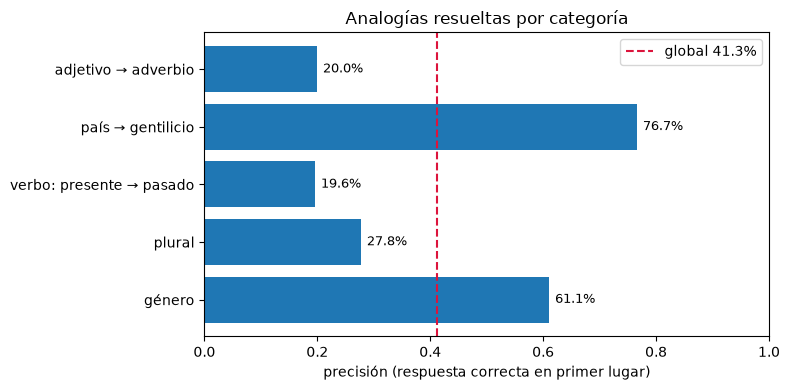

In [7]:
categorias = list(reporte["categories"])
precisiones = [reporte["categories"][c]["accuracy"] for c in categorias]

plt.figure(figsize=(8, 4))
barras = plt.barh(categorias, precisiones)
plt.axvline(reporte["accuracy"], ls="--", c="crimson", lw=1.5,
            label=f"global {reporte['accuracy']:.1%}")
for barra, valor in zip(barras, precisiones):
    plt.text(valor + 0.01, barra.get_y() + barra.get_height() / 2,
             f"{valor:.1%}", va="center", fontsize=9)
plt.xlim(0, 1)
plt.xlabel("precisión (respuesta correcta en primer lugar)")
plt.title("Analogías resueltas por categoría")
plt.legend()
plt.tight_layout()
plt.show()

El perfil de resultados es informativo:

* **`país → gentilicio` es la más fácil** (76,7%): son pares muy consistentes y
  las dos palabras aparecen en contextos temáticos casi iguales.
* **`género` funciona bien** (61,1%): la relación masculino/femenino sí quedó
  codificada como una dirección estable.
* **Las morfológicas cuestan** (plural 27,8%, verbos 19,6%, adverbios 20,0%).
  Tiene una explicación: con `context_size=2` el modelo mira una ventana muy
  chica, buena para relaciones **temáticas** pero pobre para las **sintácticas**.
  Es exactamente la hipótesis que la grilla del proyecto puede poner a prueba
  subiendo el contexto a 5 o 10.

## 5. Ver la estructura: PCA

Los embeddings viven en 50 dimensiones. PCA los proyecta a 2 quedándose con las
direcciones de mayor varianza. Si los grupos semánticos son reales, tienen que
verse separados incluso en esa proyección tan reducida.

In [8]:
from sklearn.decomposition import PCA

GRUPOS = {
    "días": ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"],
    "meses": ["enero", "febrero", "marzo", "abril", "mayo", "junio", "julio",
              "agosto", "septiembre", "octubre", "noviembre", "diciembre"],
    "números": ["uno", "dos", "tres", "cuatro", "cinco", "seis", "siete", "ocho",
                "nueve", "diez"],
    "colores": ["rojo", "azul", "verde", "negro", "blanco", "amarillo"],
    "países": ["argentina", "chile", "brasil", "españa", "francia", "italia",
               "méxico", "venezuela"],
    "familia": ["padre", "madre", "hijo", "hija", "hermano", "hermana", "esposa"],
}

palabras, etiquetas = [], []
for grupo, lista in GRUPOS.items():
    for palabra in lista:
        if palabra in VOCAB:
            palabras.append(palabra)
            etiquetas.append(grupo)

faltantes = {g: [w for w in l if w not in VOCAB] for g, l in GRUPOS.items()}
faltantes = {g: w for g, w in faltantes.items() if w}
print(f"{len(palabras)} palabras en {len(GRUPOS)} grupos")
if faltantes:
    print("fuera del vocabulario:", faltantes)

48 palabras en 6 grupos
fuera del vocabulario: {'días': ['martes', 'miércoles']}


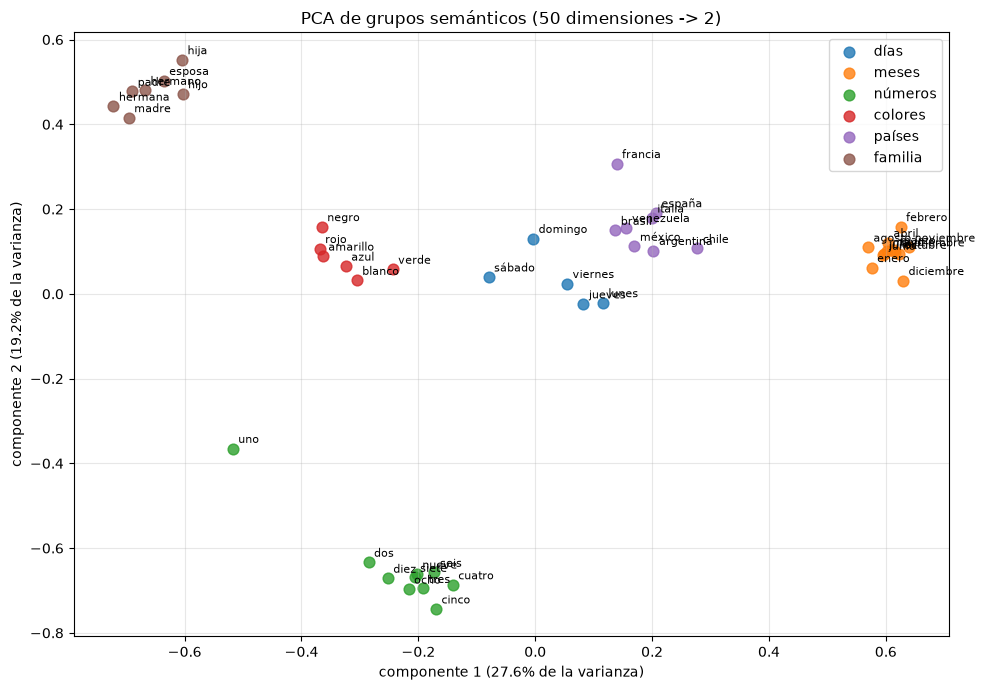

varianza explicada por las 2 componentes: 46.8%


In [9]:
matriz = np.array([E[VOCAB.index(w)] for w in palabras])
pca = PCA(n_components=2, random_state=CONFIG["seed"])
proyeccion = pca.fit_transform(matriz)

plt.figure(figsize=(10, 7))
for grupo in GRUPOS:
    idx = [i for i, e in enumerate(etiquetas) if e == grupo]
    if idx:
        plt.scatter(proyeccion[idx, 0], proyeccion[idx, 1], s=60, label=grupo, alpha=0.8)
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, proyeccion[i], fontsize=8,
                 xytext=(4, 4), textcoords="offset points")

varianza = pca.explained_variance_ratio_
plt.xlabel(f"componente 1 ({varianza[0]:.1%} de la varianza)")
plt.ylabel(f"componente 2 ({varianza[1]:.1%} de la varianza)")
plt.title("PCA de grupos semánticos (50 dimensiones -> 2)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"varianza explicada por las 2 componentes: {varianza.sum():.1%}")

> Que los grupos queden separados usando solo dos de las cincuenta dimensiones
> es notable: quiere decir que la distinción entre categorías es una de las
> direcciones dominantes del espacio, no un detalle escondido en dimensiones
> menores. La celda de arriba imprime cuánta varianza capturan esas dos.

## 6. Ver la estructura: t-SNE

PCA busca las direcciones de mayor varianza global; t-SNE, en cambio, trata de
preservar las **vecindades locales**. Suele mostrar los grupos más separados, a
costa de que las distancias entre grupos ya no signifiquen nada.

Acá se aplica sobre las 300 palabras más frecuentes, sin elegirlas a mano, para
ver qué estructura aparece sola.

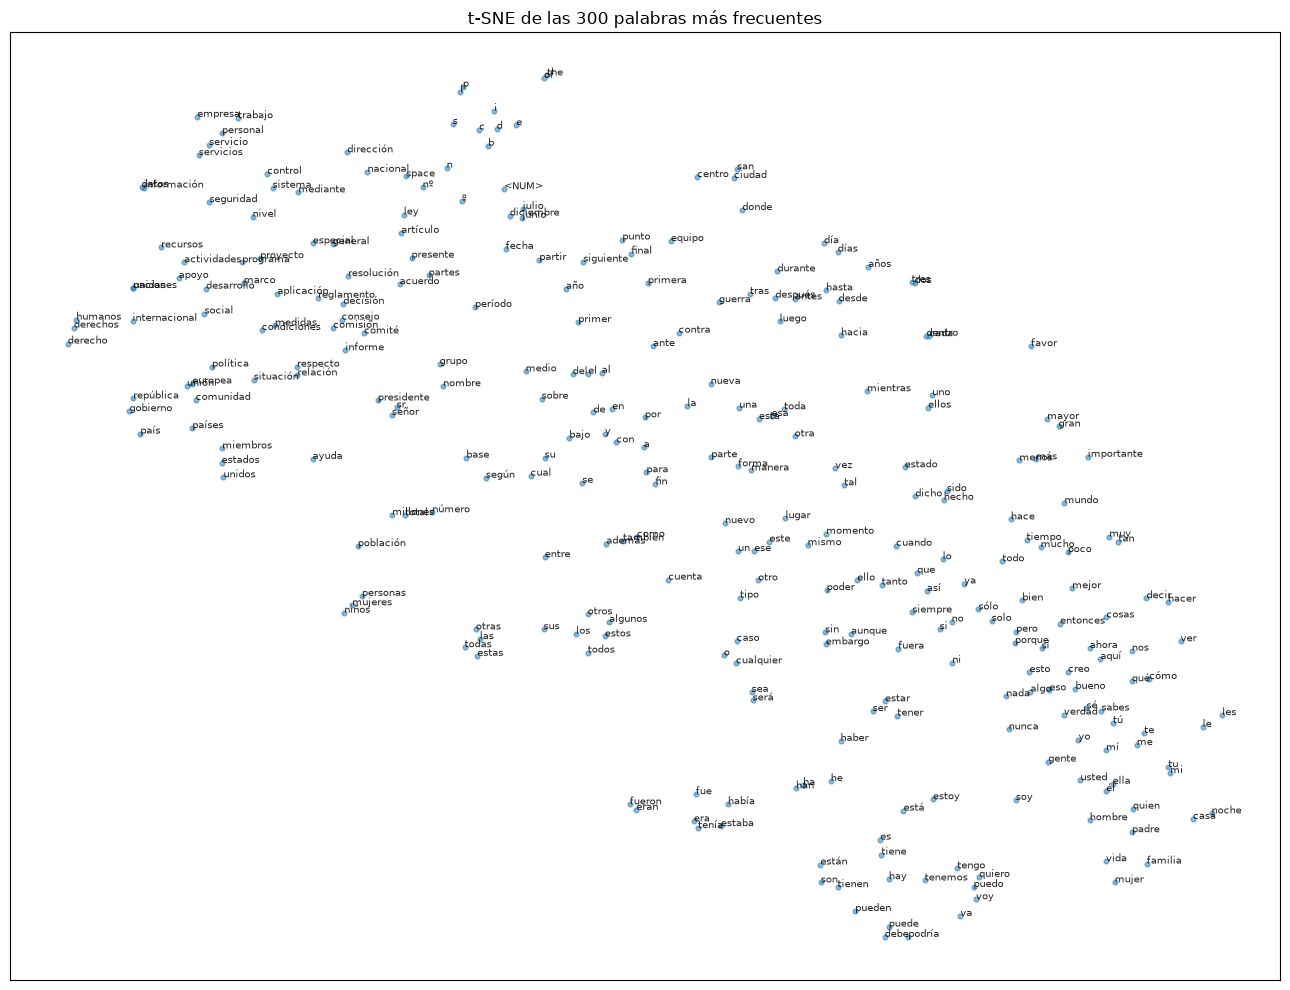

In [10]:
from sklearn.manifold import TSNE

N = 300
indices = list(range(1, N + 1))          # se saltea <UNK>
sub = E[indices]

tsne = TSNE(n_components=2, perplexity=25, random_state=CONFIG["seed"],
            init="pca", max_iter=1000)
puntos = tsne.fit_transform(sub)

plt.figure(figsize=(13, 10))
plt.scatter(puntos[:, 0], puntos[:, 1], s=12, alpha=0.5)
for i, indice in enumerate(indices):
    plt.annotate(VOCAB.word(indice), puntos[i], fontsize=7, alpha=0.85)
plt.title(f"t-SNE de las {N} palabras más frecuentes")
plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

## 7. Exportación al formato Word2Vec

El paso que hace que los embeddings sirvan **fuera** de este proyecto. El formato
lo definió el word2vec original y lo entienden gensim, spaCy y casi cualquier
herramienta de NLP.

In [11]:
destino_txt = export_from_config(CONFIG)
destino_bin = export_from_config(CONFIG, binary=True)

print(f"{destino_txt.name:<28} {destino_txt.stat().st_size / 1024**2:>6.2f} MB")
print(f"{destino_bin.name:<28} {destino_bin.stat().st_size / 1024**2:>6.2f} MB")
print()
print("Las primeras líneas del archivo de texto:")
with destino_txt.open(encoding="utf-8") as f:
    for i, linea in enumerate(f):
        if i > 3:
            break
        partes = linea.split()
        if i == 0:
            print(f"  encabezado: {linea.strip()}  <- palabras y dimensión")
        else:
            print(f"  {partes[0]:<8} {' '.join(partes[1:6])} ... ({len(partes) - 1} valores)")

piloto_5k_50_2.txt             2.31 MB
piloto_5k_50_2.bin             0.99 MB

Las primeras líneas del archivo de texto:
  encabezado: 4999 50  <- palabras y dimensión
  de       -0.055610 -0.017086 0.165185 0.109041 -0.008628 ... (50 valores)
  la       0.089923 0.044921 0.245133 0.051562 0.081072 ... (50 valores)
  en       0.104708 -0.017643 0.237318 0.118121 0.050934 ... (50 valores)


`<UNK>` **no se exporta**: por eso el encabezado dice 4.999 y no 5.000. Su vector
nunca se entrenó (sección 1), así que publicarlo sería publicar ruido.

In [12]:
# La prueba de fuego: que gensim lo lea y dé los mismos resultados
from gensim.models import KeyedVectors

kv_txt = KeyedVectors.load_word2vec_format(destino_txt, binary=False)
kv_bin = KeyedVectors.load_word2vec_format(destino_bin, binary=True)

print(f"texto  : {len(kv_txt.index_to_key):,} palabras, dimensión {kv_txt.vector_size}")
print(f"binario: {len(kv_bin.index_to_key):,} palabras, dimensión {kv_bin.vector_size}")
print(f"los dos formatos coinciden: "
      f"{np.allclose(kv_txt['lunes'], kv_bin['lunes'], atol=1e-5)}")
print()

print("Vecinos según gensim vs según nuestro código:")
for palabra in ["lunes", "rojo", "argentina"]:
    de_gensim = [w for w, _ in kv_txt.most_similar(palabra, topn=5)]
    de_nuestro = [w for w, _ in nearest_neighbors(palabra, E, VOCAB, k=5)]
    print(f"  {palabra}")
    print(f"    gensim  : {de_gensim}")
    print(f"    nuestro : {de_nuestro}")
    print(f"    iguales : {de_gensim == de_nuestro}")

texto  : 4,999 palabras, dimensión 50
binario: 4,999 palabras, dimensión 50
los dos formatos coinciden: True

Vecinos según gensim vs según nuestro código:
  lunes
    gensim  : ['viernes', 'jueves', 'sábado', 'horario', 'horas']
    nuestro : ['viernes', 'jueves', 'sábado', 'horario', 'horas']
    iguales : True
  rojo
    gensim  : ['azul', 'blanco', 'negro', 'amarillo', 'color']
    nuestro : ['azul', 'blanco', 'negro', 'amarillo', 'color']
    iguales : True
  argentina
    gensim  : ['argentino', 'republica', 'chile', 'paraguay', 'mendoza']
    nuestro : ['argentino', 'republica', 'chile', 'paraguay', 'mendoza']
    iguales : True


In [13]:
# Y que las analogías también funcionen desde gensim
print("Analogías resueltas por gensim sobre el archivo exportado:")
for positivos, negativos in [(["mujer", "rey"], ["hombre"]),
                             (["españa", "roma"], ["madrid"]),
                             (["dijo", "hace"], ["dice"])]:
    resultado = kv_txt.most_similar(positive=positivos, negative=negativos, topn=3)
    consulta = " + ".join(positivos) + " - " + " - ".join(negativos)
    print(f"  {consulta:<28} -> " + ", ".join(f"{w} ({s:.2f})" for w, s in resultado))

Analogías resueltas por gensim sobre el archivo exportado:
  mujer + rey - hombre         -> isabel (0.71), reina (0.70), trono (0.59)
  españa + roma - madrid       -> italia (0.73), francia (0.70), grecia (0.70)
  dijo + hace - dice           -> hacía (0.74), pensaba (0.69), hice (0.67)


Que gensim reproduzca exactamente los mismos vecinos y las mismas analogías es la
confirmación de que el archivo está bien escrito: no hay desfasajes de índices,
ni de orden, ni de precisión.

## Conclusiones de la Fase 6

- **Vecinos cercanos:** el modelo agrupó días, meses, números, colores, países y
  cargos sin supervisión alguna.
- **Analogías:** funcionan para las relaciones semánticas (`madrid : españa ::
  roma : italia` acierta primero) y flojean en las morfológicas.
- **Precisión global de 41,3%** sobre el set de analogías, con un perfil claro:
  las relaciones temáticas se resuelven bien y las sintácticas no. Es consistente
  con `context_size=2`, y es una hipótesis directamente comprobable subiendo el
  contexto en la Fase 7.
- **La estructura es visible**: PCA separa los grupos semánticos con solo dos
  componentes.
- **La exportación es válida**: gensim lee los formatos de texto y binario y
  reproduce exactamente los mismos vecinos y analogías.

**Siguiente paso:** Fase 7 — entrenar otras configuraciones de la grilla y
compararlas con estas métricas en `06_comparacion_configuraciones.ipynb`.